<a href="https://colab.research.google.com/github/jwlee95/DSP_w_Python2026/blob/main/PDSP_ch04_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4장 예제:   
Algorithm 4.1(표본화-양자화-영차홀드 복원 파이프라인)을  구현하고,   
(1) 표본화-양자화-ZOH 복원을 한 그림으로 재현하며,   
(2) 4.2.4절의 에일리어싱 수치 예시(f0=7 Hz, fs=10 Hz)를 시각적으로 검증하고,   
(3) 4.4.3절에서 유도한 SQNR 공식(식 4.32, 6.02B+1.76 dB)을 시뮬레이션으로 검증한다.   

> 필요 라이브러리: numpy, matplotlib  (pip install numpy matplotlib)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ideal_sampling(A: float, f0: float, phi: float, fs: float, T_dur: float):
    """
    Algorithm 4.1의 1~5행. 정현파 x(t)=A cos(2*pi*f0*t+phi)를 fs로 표본화한다.
    반환값: (t_s, x_s)
    """
    N = int(np.floor(fs * T_dur))
    n = np.arange(0, N + 1)
    t_s = n / fs
    x_s = A * np.cos(2 * np.pi * f0 * t_s + phi)
    return t_s, x_s


### `ideal_sampling` 함수 설명

이 함수는 연속 시간 정현파 신호 $x(t)$를 이산 시간 샘플 $x[n]$로 변환하는 이상적인 표본화 과정을 시뮬레이션합니다.

입력 신호는 다음과 같은 형태의 정현파로 가정합니다:
$x(t) = A \cos(2\pi f_0 t + \phi)$

여기서:
- $A$: 진폭 (Amplitude)
- $f_0$: 주파수 (Frequency in Hz)
- $\phi$: 위상 (Phase in radians)

**표본화 과정:**

1. **표본화 시간 계산:** 신호는 표본화 주파수 $f_s$로 표본화됩니다. 표본화 간격은 $T_s = 1/f_s$ 입니다. 각 샘플은 $t_n = nT_s = n/f_s$ 시점에서 추출됩니다.

2. **총 샘플 개수:** 주어진 지속 시간 $T_{dur}$ 동안의 총 샘플 개수 $N$은 $N = \lfloor f_s T_{dur} \rfloor$ 로 계산됩니다. `np.floor`를 사용하여 정수 부분만 취합니다.

3. **시간 인덱스:** $n$은 $0$부터 $N$까지의 정수 인덱스 배열입니다.

4. **표본화된 시간 $t_s$:** 각 샘플이 추출되는 시간 지점들의 배열입니다.
$t_s = [0/f_s, 1/f_s, 2/f_s, \ldots, N/f_s]$

5. **표본화된 신호 $x_s$:** 각 $t_s$ 값에서 원본 연속 신호 $x(t)$를 평가하여 얻은 이산 시간 샘플들의 배열입니다.
$x_s[n] = A \cos(2\pi f_0 (n/f_s) + \phi)$

In [3]:
def quantize_uniform(x: np.ndarray, A_range: float, B: int):
    """
    Algorithm 4.1의 6~9행. 균등 양자화기 (식 4.25, 4.26).
    A_range: 양자화기의 전체범위(full-scale) 진폭 (즉 범위는 [-A_range, A_range]).
    반환값: (x_q, delta)
    """
    delta = 2 * A_range / (2 ** B)
    x_q = delta * np.round(x / delta)
    return x_q, delta


### `quantize_uniform` 함수 설명

이 함수는 주어진 아날로그 신호 샘플 $x$를 균일 양자화하여 이산적인 값으로 변환합니다.

**균일 양자화 과정:**

1. **양자화 스텝 크기($\Delta$) 계산:**
   양자화기의 전체 범위는 $[-A_{range}, A_{range}]$이며, $B$ 비트 양자화기는 $2^B$개의 양자화 레벨을 가집니다. 따라서, 각 양자화 스텝의 크기 $\Delta$는 다음과 같이 계산됩니다:
   $\Delta = \frac{2 A_{range}}{2^B}$

2. **양자화된 값($x_q$) 계산:**
   입력 샘플 $x$는 가장 가까운 양자화 레벨로 반올림됩니다. 이는 $x$를 $\Delta$로 나눈 후 반올림하고, 다시 $\Delta$를 곱하여 수행됩니다:
   $x_q = \Delta \cdot \text{round}\left(\frac{x}{\Delta}\right)$

여기서:
- $x$: 양자화할 아날로그 신호 샘플 (넘파이 배열)
- $A_{range}$: 양자화기의 전체 범위 진폭 (e.g., 1.0 for range [-1.0, 1.0])
- $B$: 양자화 비트 수 (Bit depth)
- $x_q$: 양자화된 신호 샘플 (넘파이 배열)
- $\Delta$: 양자화 스텝 크기

In [4]:
def zoh_reconstruct(t_s: np.ndarray, x_q: np.ndarray, fs: float, t_r: np.ndarray):
    """
    Algorithm 4.1의 10~17행. 영차홀드(ZOH) 복원 (식 4.22, 4.23).
    재구성 그리드 t_r의 각 점에서, 해당 구간의 표본값을 그대로 유지한다.
    """
    N = len(x_q) - 1
    idx = np.floor(t_r * fs).astype(int)
    idx = np.clip(idx, 0, N)
    x_r = x_q[idx]
    return x_r


### `zoh_reconstruct` 함수 설명

이 함수는 영차 홀드(Zero-Order Hold, ZOH) 방식을 사용하여 양자화된 이산 신호 $x_q[n]$로부터 연속 시간 신호 $x_r(t)$를 재구성합니다.

**ZOH 복원 과정:**

ZOH 복원은 각 표본 값 $x_q[n]$을 다음 표본이 나타나기 전까지의 전체 표본화 간격 동안 유지(홀드)하는 방식입니다. 이는 계단 형태의 신호를 생성합니다.

1. **시간 인덱스 계산:** 재구성할 시간 그리드 $t_r$의 각 시점 $t$에 대해, 해당 시점이 속하는 표본화 구간의 시작 인덱스 $n$을 찾습니다.
   $n = \lfloor t \cdot f_s \rfloor$
   여기서 $f_s$는 표본화 주파수입니다.

2. **표본값 선택:** 계산된 인덱스 $n$에 해당하는 양자화된 표본 값 $x_q[n]$을 선택합니다.
   $x_r(t) = x_q[n]$ for $nT_s \le t < (n+1)T_s$
   ($T_s = 1/f_s$는 표본화 주기)

3. **클리핑:** 계산된 인덱스가 표본 배열의 유효 범위를 벗어나지 않도록 `np.clip`을 사용하여 조정합니다.

여기서:
- $t_s$: 표본화된 시간 $t_n$ 배열
- $x_q$: 양자화된 신호 샘플 $x_q[n]$ 배열
- $f_s$: 표본화 주파수
- $t_r$: 재구성할 새로운 시간 그리드 $t$ 배열
- $x_r$: ZOH 방식으로 재구성된 연속 신호 $x_r(t)$ 배열

In [5]:
def compute_sqnr_empirical_db(x: np.ndarray, x_q: np.ndarray) -> float:
    """측정된 SQNR(dB) = 10*log10(신호전력 / 잡음전력)."""
    e = x_q - x
    signal_power = np.mean(x ** 2)
    noise_power = np.mean(e ** 2)
    return 10 * np.log10(signal_power / noise_power)


### `compute_sqnr_empirical_db` 함수 설명

이 함수는 신호 대 양자화 잡음비(Signal-to-Quantization-Noise Ratio, SQNR)를 시뮬레이션 결과로부터 직접 측정(Empirical measurement)합니다.

**SQNR 계산 과정:**

1. **양자화 잡음(Error) 계산:**
   원본 신호 샘플 $x$와 양자화된 신호 샘플 $x_q$의 차이를 잡음 $e$로 정의합니다.
   $e = x_q - x$

2. **신호 및 잡음 전력(Power) 계산:**
   각 신호의 평균 제곱값(Mean Square)을 통해 전력을 구합니다.
   - 신호 전력 ($P_{signal}$): $E[x^2] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]^2$
   - 잡음 전력 ($P_{noise}$): $E[e^2] = \frac{1}{N}\sum_{n=0}^{N-1} e[n]^2$

3. **SQNR(dB) 변환:**
   신호 전력과 잡음 전력의 비를 로그 스케일(데시벨, dB)로 변환합니다.
   $\text{SQNR}_{dB} = 10 \log_{10} \left( \frac{P_{signal}}{P_{noise}} \right)$

여기서:
- $x$: 원본 표본화 신호
- $x_q$: 양자화된 신호
- $e$: 양자화 오차 (Quantization error)

In [6]:
def sqnr_theoretical_db(B: int) -> float:
    """식 (4.32): 6.02*B + 1.76 [dB]."""
    return 6.02 * B + 1.76


### `sqnr_theoretical_db` 함수 설명

이 함수는 교재의 식 (4.32)를 바탕으로, 비트 수 $B$에 따른 이론적인 최대 신호 대 양자화 잡음비(SQNR)를 계산합니다.

**이론적 배경:**

균등 양자화기에서 양자화 오차 $e$가 $[-\Delta/2, \Delta/2]$ 범위에서 균등 분포(Uniform Distribution)를 따른다고 가정할 때, 양자화 잡음의 전력은 $P_{noise} = \Delta^2/12$가 됩니다. 이를 바탕으로 최대 진폭 $A$를 가진 정현파 신호에 대해 유도된 SQNR 공식은 다음과 같습니다.

$$\text{SQNR}_{dB} \approx 6.02B + 1.76 \text{ [dB]}$$

**함수 로직:**

1. **입력:** 양자화 비트 수 $B$ (Bit depth).
2. **계산:** 위 공식을 그대로 적용하여 값을 반환합니다.
   - $6.02 \times B$: 비트가 1 증가할 때마다 SQNR이 약 6dB씩 개선됨을 의미합니다.
   - $1.76$: 정현파 신호의 특성에서 기인한 상수값입니다.

이 식은 실제 시뮬레이션 측정값과 비교하여 양자화 성능을 검증하는 기준점으로 사용됩니다.

---

### 메인 실행 블록 (`if __name__ == "__main__":`)

이 셀은 앞서 정의한 함수들을 사용하여 알고리즘 4.1의 전체 과정을 실행하고, 세 가지 주요 시나리오를 검증 및 시각화합니다.

**1. 표본화-양자화-ZOH 복원 데모**
- 나이퀴스트 주파수를 만족하는 조건($f_s > 2f_0$)에서 신호를 표본화하고 4비트로 양자화한 후, 영차 홀드(ZOH)로 복원했을 때의 계단 현상을 시각화합니다.

**2. 에일리어싱(Aliasing) 시각적 검증**
- $f_0=7$ Hz 신호를 두 가지 조건으로 표본화합니다.
  - **Case A**: $f_s=50$ Hz (적절한 표본화)
  - **Case B**: $f_s=10$ Hz (에일리어싱 발생)
- 식 (4.17)에 의해 $f_{alias} = |f_s - f_0| = 3$ Hz로 나타나는 에일리어싱 현상을 그래프로 확인합니다.

**3. SQNR 공식 시뮬레이션 검증**
- 비트 수($B$)를 4에서 12까지 변화시키며 실제 측정된 SQNR과 이론값($6.02B + 1.76$ dB)을 비교합니다.

**4. 데이터 시각화**
- **Figure 1**: 시간 영역에서의 ZOH 복원 결과.
- **Figure 2**: 에일리어싱 전/후의 표본 점들과 겉보기 주파수(Apparent frequency) 비교.
- **Figure 3**: 비트 수 증가에 따른 이론적 SQNR과 실제 측정값의 일치 여부 확인.

=== (1) 표본화-양자화-ZOH 복원 데모 ===
fs=50.0 Hz, B=4 bit, 양자화 계단 Delta=0.1250

=== (2) 에일리어싱 데모 ===
f0=7.0 Hz, fs_aliased=10.0 Hz -> 식(4.17)에 의한 예측 에일리어스 주파수 = 3.0 Hz

=== (3) SQNR 검증 (이론값 vs 측정값, dB) ===
B= 4 bit | 이론:  25.84 dB | 측정:  26.10 dB | 차이: 0.261 dB
B= 5 bit | 이론:  31.86 dB | 측정:  31.79 dB | 차이: 0.073 dB
B= 6 bit | 이론:  37.88 dB | 측정:  38.93 dB | 차이: 1.053 dB
B= 7 bit | 이론:  43.90 dB | 측정:  45.28 dB | 차이: 1.382 dB
B= 8 bit | 이론:  49.92 dB | 측정:  50.60 dB | 차이: 0.681 dB
B= 9 bit | 이론:  55.94 dB | 측정:  57.53 dB | 차이: 1.590 dB
B=10 bit | 이론:  61.96 dB | 측정:  62.36 dB | 차이: 0.396 dB
B=11 bit | 이론:  67.98 dB | 측정:  67.93 dB | 차이: 0.052 dB
B=12 bit | 이론:  74.00 dB | 측정:  74.96 dB | 차이: 0.955 dB


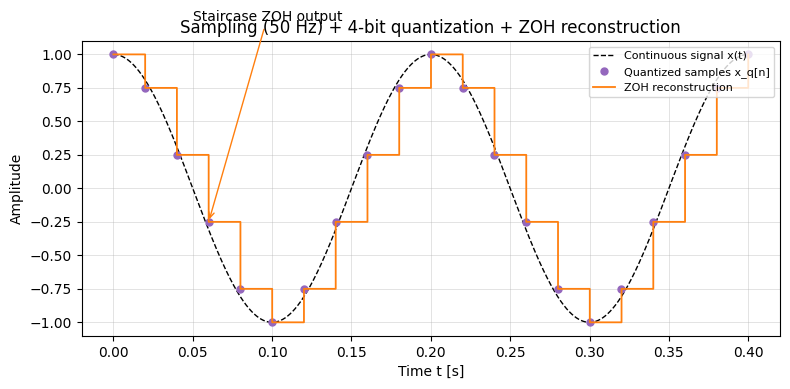

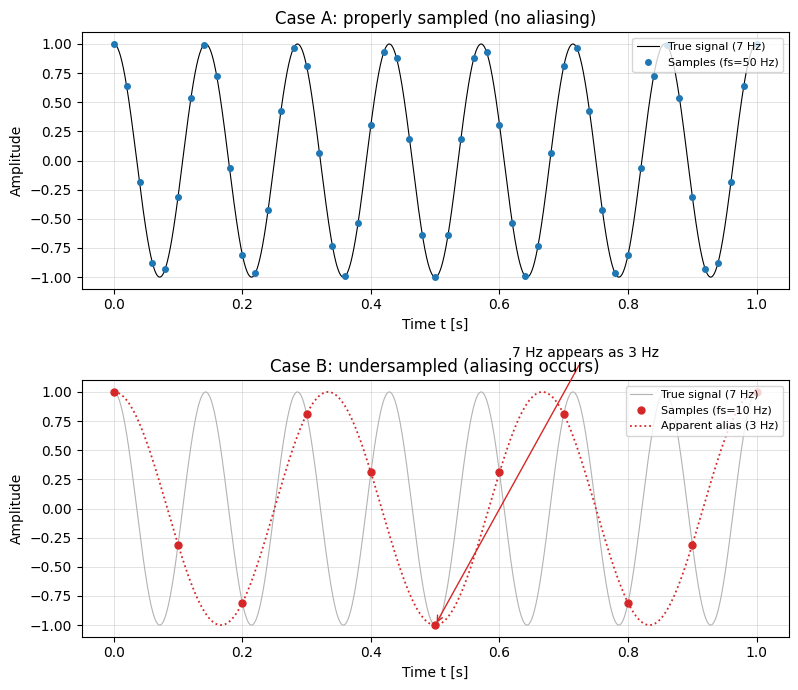

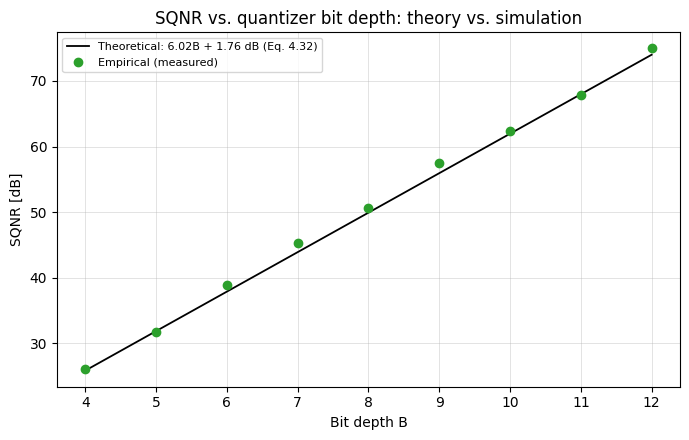

In [7]:
if __name__ == "__main__":
    # ------------------------------------------------------------------
    # (1) 표본화 + 양자화 + ZOH 복원 데모 (fs > 2*f_max, 에일리어싱 없음)
    # ------------------------------------------------------------------
    A, f0, phi = 1.0, 5.0, 0.0
    fs1, T_dur1, B_demo = 50.0, 0.4, 4
    t_s1, x_s1 = ideal_sampling(A, f0, phi, fs1, T_dur1)
    x_q1, delta1 = quantize_uniform(x_s1, A, B_demo)
    t_fine1 = np.linspace(0, T_dur1, 2000)
    x_fine1 = A * np.cos(2 * np.pi * f0 * t_fine1 + phi)
    x_zoh1 = zoh_reconstruct(t_s1, x_q1, fs1, t_fine1)

    print("=== (1) 표본화-양자화-ZOH 복원 데모 ===")
    print(f"fs={fs1} Hz, B={B_demo} bit, 양자화 계단 Delta={delta1:.4f}")

    # ------------------------------------------------------------------
    # (2) 에일리어싱 데모: f0=7 Hz를 fs=50 Hz(정상)와 fs=10 Hz(에일리어싱)로 비교
    #     (4.2.4절 수치 예시 재현)
    # ------------------------------------------------------------------
    f0_alias, T_dur2 = 7.0, 1.0
    fs_clean, fs_aliased = 50.0, 10.0
    t_fine2 = np.linspace(0, T_dur2, 4000)
    x_fine2 = np.cos(2 * np.pi * f0_alias * t_fine2)

    t_s_clean, x_s_clean = ideal_sampling(1.0, f0_alias, 0.0, fs_clean, T_dur2)
    t_s_aliased, x_s_aliased = ideal_sampling(1.0, f0_alias, 0.0, fs_aliased, T_dur2)

    f_alias_theory = fs_aliased - f0_alias  # 식 (4.17)
    x_alias_envelope = np.cos(2 * np.pi * f_alias_theory * t_fine2)

    print("\n=== (2) 에일리어싱 데모 ===")
    print(f"f0={f0_alias} Hz, fs_aliased={fs_aliased} Hz -> "
          f"식(4.17)에 의한 예측 에일리어스 주파수 = {f_alias_theory} Hz")

    # ------------------------------------------------------------------
    # (3) SQNR 검증: 식(4.32) 이론값과 시뮬레이션 측정값 비교
    # ------------------------------------------------------------------
    B_list = np.arange(4, 13)
    fs3, T_dur3, f0_3 = 1000.0, 1.0, 5.0
    t_s3, x_s3 = ideal_sampling(1.0, f0_3, 0.0, fs3, T_dur3)

    sqnr_emp, sqnr_theory = [], []
    for B in B_list:
        x_q3, _ = quantize_uniform(x_s3, 1.0, int(B))
        sqnr_emp.append(compute_sqnr_empirical_db(x_s3, x_q3))
        sqnr_theory.append(sqnr_theoretical_db(int(B)))

    print("\n=== (3) SQNR 검증 (이론값 vs 측정값, dB) ===")
    for B, e, t in zip(B_list, sqnr_emp, sqnr_theory):
        print(f"B={B:2d} bit | 이론: {t:6.2f} dB | 측정: {e:6.2f} dB | 차이: {abs(t - e):5.3f} dB")

    # ------------------------------------------------------------------
    # (4) 시각화
    # ------------------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(8, 4), facecolor='white')
    ax1.set_facecolor('white')
    ax1.grid(True, linewidth=0.5, alpha=0.5)
    ax1.plot(t_fine1, x_fine1, color='black', linewidth=1.0, linestyle='--',
              label='Continuous signal x(t)')
    ax1.plot(t_s1, x_q1, 'o', color='tab:purple', markersize=5,
              label='Quantized samples x_q[n]')
    ax1.plot(t_fine1, x_zoh1, color='tab:orange', linewidth=1.3, drawstyle='steps-post',
              label='ZOH reconstruction')
    ax1.set_title(f'Sampling ({fs1:.0f} Hz) + {B_demo}-bit quantization + ZOH reconstruction')
    ax1.set_xlabel('Time t [s]')
    ax1.set_ylabel('Amplitude')
    ax1.annotate('Staircase ZOH output', xy=(t_fine1[300], x_zoh1[300]), xytext=(0.05, 1.25),
                  arrowprops=dict(arrowstyle='->', color='tab:orange'))
    ax1.legend(loc='upper right', fontsize=8)
    fig1.tight_layout()

    fig2, axes2 = plt.subplots(2, 1, figsize=(8, 7), facecolor='white')
    for ax in axes2:
        ax.set_facecolor('white')
        ax.grid(True, linewidth=0.5, alpha=0.5)

    axes2[0].plot(t_fine2, x_fine2, color='black', linewidth=0.8,
                   label=f'True signal ({f0_alias:.0f} Hz)')
    axes2[0].plot(t_s_clean, x_s_clean, 'o', color='tab:blue', markersize=4,
                   label=f'Samples (fs={fs_clean:.0f} Hz)')
    axes2[0].set_title('Case A: properly sampled (no aliasing)')
    axes2[0].set_xlabel('Time t [s]')
    axes2[0].set_ylabel('Amplitude')
    axes2[0].legend(loc='upper right', fontsize=8)

    axes2[1].plot(t_fine2, x_fine2, color='0.7', linewidth=0.8,
                   label=f'True signal ({f0_alias:.0f} Hz)')
    axes2[1].plot(t_s_aliased, x_s_aliased, 'o', color='tab:red', markersize=5,
                   label=f'Samples (fs={fs_aliased:.0f} Hz)')
    axes2[1].plot(t_fine2, x_alias_envelope, color='tab:red', linewidth=1.3, linestyle=':',
                   label=f'Apparent alias ({f_alias_theory:.0f} Hz)')
    axes2[1].set_title('Case B: undersampled (aliasing occurs)')
    axes2[1].set_xlabel('Time t [s]')
    axes2[1].set_ylabel('Amplitude')
    axes2[1].annotate(f'{f0_alias:.0f} Hz appears as {f_alias_theory:.0f} Hz',
                        xy=(0.5, x_alias_envelope[2000]), xytext=(0.62, 1.3),
                        arrowprops=dict(arrowstyle='->', color='tab:red'))
    axes2[1].legend(loc='upper right', fontsize=8)
    fig2.tight_layout()

    fig3, ax3 = plt.subplots(figsize=(7, 4.5), facecolor='white')
    ax3.set_facecolor('white')
    ax3.grid(True, linewidth=0.5, alpha=0.5)
    ax3.plot(B_list, sqnr_theory, color='black', linewidth=1.3,
              label='Theoretical: 6.02B + 1.76 dB (Eq. 4.32)')
    ax3.plot(B_list, sqnr_emp, 'o', color='tab:green', markersize=6,
              label='Empirical (measured)')
    ax3.set_title('SQNR vs. quantizer bit depth: theory vs. simulation')
    ax3.set_xlabel('Bit depth B')
    ax3.set_ylabel('SQNR [dB]')
    ax3.legend(loc='upper left', fontsize=8)
    fig3.tight_layout()

    plt.show()